In [20]:
#学习率的选择
import numpy as np
import copy
x_train=np.array([[952,2,1,65],[1244,3,2,64],[1947,3,2,17]])
y_train=np.array([271.5,232,509.8])
def cost_function(x,y,w,b):
    m=x.shape[0]
    j_wb=0
    for i in range(m):
        f_wb=np.dot(x[i],w)+b
        j_wb_i=(f_wb-y[i])**2
        j_wb+=j_wb_i
    j_wb=j_wb/(2*m)
    return j_wb

#计算偏导，返回一个数组，一个整数
def partial(x,y,w,b):
    m,n=x.shape          #其中m,n分别为x的行列数
    dj_dw=np.zeros(n)
    dj_db=0
    """
       偏导的公式中，当代价函数cost_function对w偏导时，外层的函数正常求导;
       里层的函数wx+b,由于w和x系同维度，每一个w对x的改变都不同，所以w对x的影响应当考虑每一项。
    """
    for i in range(m):
        err=np.dot(x[i],w)+b-y[i]
        for j in range(n):
            dj_dw[j]+=err*(x[i,j])
        dj_db+=err
    dj_dw=dj_dw/m
    dj_db=dj_db/m
    return dj_dw,dj_db

#梯度下降：w=w-a(dj_dw) b=b-a(dj_db)
def gradient_descent(x,y,w_in,b_in,alpha,num_iters,cost_function,partial):
    j_history=[]
    b=b_in
    w=copy.deepcopy(w_in)
    
    for i in range(num_iters):
        dj_dw, dj_db = partial(x,y,w,b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        j_history.append(cost_function(x,y,w,b))
        # 每100次打印一次
        print(f"Iteration {i:4d}  Cost: {j_history[-1]:.6f} w0:{w[0]:0.3e} w1:{w[1]:0.3e} w2:{w[2]:0.3e} w3:{w[3]:0.3e} b:{b:0.3e} dj_w0:{dj_dw[0]:0.3e} dj_w1:{dj_dw[1]:0.3e} dj_w2:{dj_dw[2]:0.3e} dj_w3:{dj_dw[3]:0.3e} dj_db:{dj_db:0.3e}")
    return w, b, j_history

w_init=np.zeros(x_train.shape[1])
print(w_init)
b_init=0.
alpha=1e-7
num_iters=10
w_fina,b_fina,j_list=gradient_descent(x_train,y_train,w_init,b_init,alpha,num_iters,cost_function,partial)
print(f"梯度下降最后得到的值为 w:{w_fina} b:{b_fina:.2f}")


[0. 0. 0. 0.]
Iteration    0  Cost: 40959.194369 w0:5.132e-02 w1:9.228e-05 w2:5.850e-05 w3:1.372e-03 b:3.378e-05 dj_w0:-5.132e+05 dj_w1:-9.228e+02 dj_w2:-5.850e+02 dj_w3:-1.372e+04 dj_db:-3.378e+02
Iteration    1  Cost: 26159.609960 w0:9.195e-02 w1:1.649e-04 w2:1.044e-04 w3:2.445e-03 b:6.046e-05 dj_w0:-4.063e+05 dj_w1:-7.263e+02 dj_w2:-4.595e+02 dj_w3:-1.073e+04 dj_db:-2.668e+02
Iteration    2  Cost: 16883.821762 w0:1.241e-01 w1:2.220e-04 w2:1.405e-04 w3:3.281e-03 b:8.153e-05 dj_w0:-3.217e+05 dj_w1:-5.707e+02 dj_w2:-3.601e+02 dj_w3:-8.362e+03 dj_db:-2.107e+02
Iteration    3  Cost: 11070.122679 w0:1.496e-01 w1:2.667e-04 w2:1.686e-04 w3:3.930e-03 b:9.814e-05 dj_w0:-2.547e+05 dj_w1:-4.475e+02 dj_w2:-2.814e+02 dj_w3:-6.488e+03 dj_db:-1.662e+02
Iteration    4  Cost: 7426.319188 w0:1.697e-01 w1:3.017e-04 w2:1.905e-04 w3:4.430e-03 b:1.112e-04 dj_w0:-2.016e+05 dj_w1:-3.500e+02 dj_w2:-2.190e+02 dj_w3:-5.004e+03 dj_db:-1.310e+02
Iteration    5  Cost: 5142.517339 w0:1.857e-01 w1:3.290e-04 w2:2.07

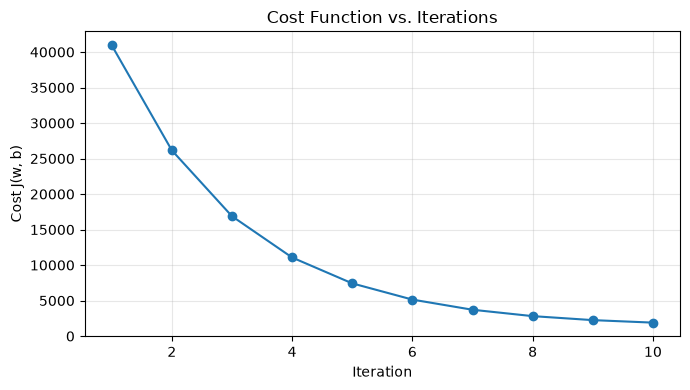

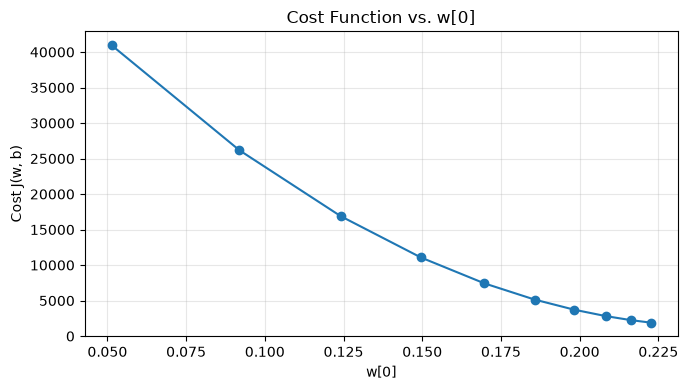

In [21]:
import matplotlib.pyplot as plt

# 重新执行梯度下降，并记录每次迭代后的权重与代价
w_plot = copy.deepcopy(w_init)
b_plot = b_init
w_history = []
cost_history = []

for _ in range(num_iters):
    dj_dw, dj_db = partial(x_train, y_train, w_plot, b_plot)
    w_plot = w_plot - alpha * dj_dw
    b_plot = b_plot - alpha * dj_db
    w_history.append(w_plot.copy())
    cost_history.append(cost_function(x_train, y_train, w_plot, b_plot))

w_history = np.array(w_history)
iterations = np.arange(1, num_iters + 1)

# 代价函数与迭代次数的关系
plt.figure(figsize=(7, 4))
plt.plot(iterations, cost_history, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w, b)')
plt.title('Cost Function vs. Iterations')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 梯度下降轨迹中，代价函数与 w[0] 的关系
plt.figure(figsize=(7, 4))
plt.plot(w_history[:, 0], cost_history, marker='o')
plt.xlabel('w[0]')
plt.ylabel('Cost J(w, b)')
plt.title('Cost Function vs. w[0]')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
